In [68]:
# Imports Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
df = pd.read_csv('teleconnect.csv')
df.head()

# Check shape and structure of Data
print("=== DATASET OVERVIEW ===")
print('Shape:', df.shape)
print()

# Check data types
print(df.dtypes)

# Check missing values 
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# Check for whitespace strings in TotalCharges
print("\n=== Hidden blanks in TotalCharges: ===")
print((df['TotalCharges'].str.strip() == '').sum())

print("\n=== DATA DESCRIPTION ===")
df.describe()


=== DATASET OVERVIEW ===
Shape: (7043, 21)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== MISSING VALUES ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



=== EDA VISUALIZATION ===


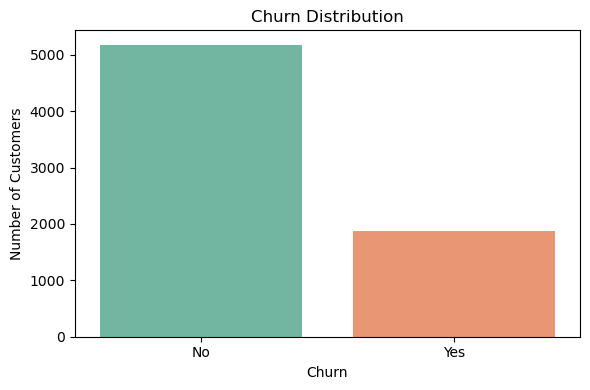

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


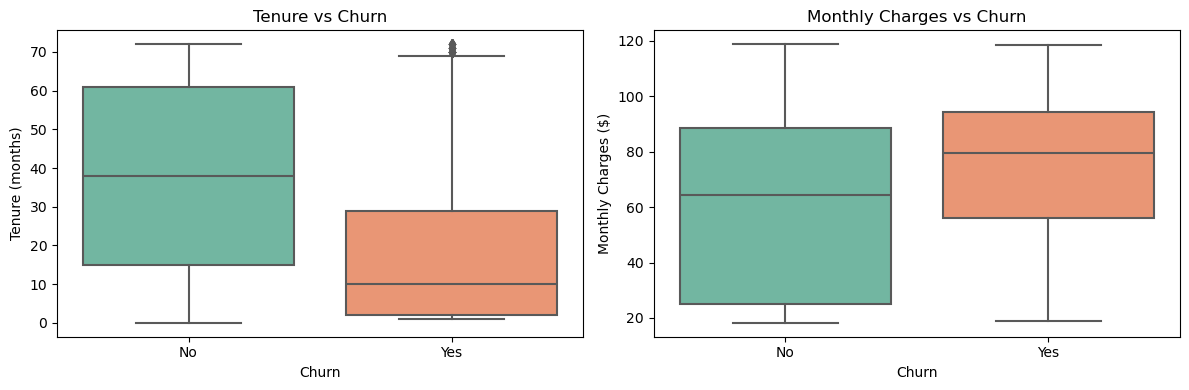

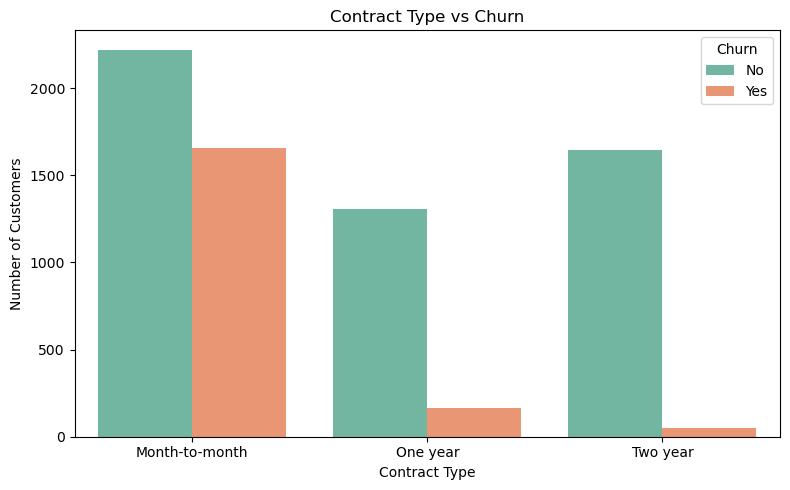

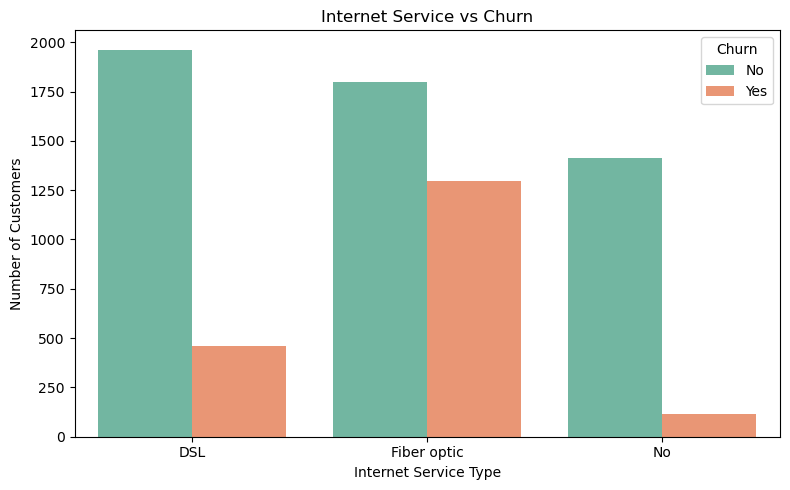

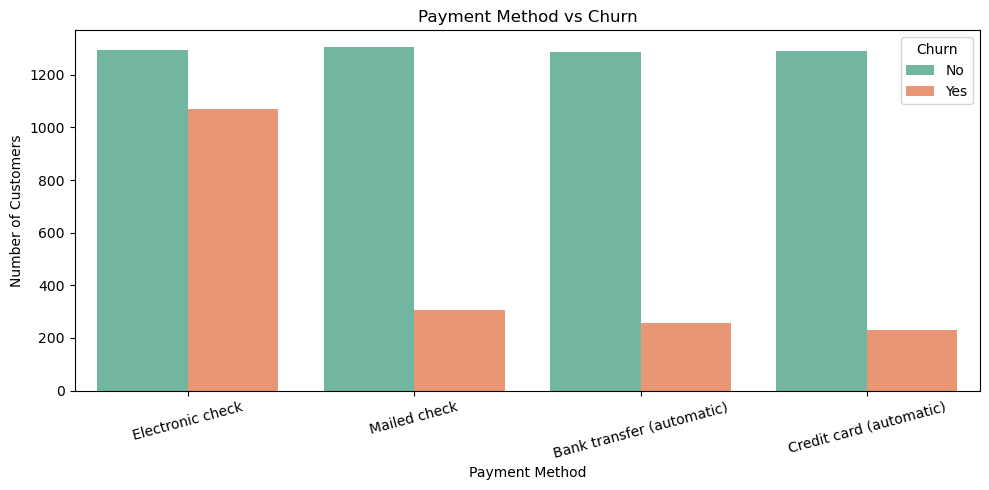

In [69]:
# STATISTICAL SUMMARY

# Churn Distribution
print("\n=== EDA VISUALIZATION ===")
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).mul(100).round(1))


# Numerical Features vs Churn : check whether tenure and monthly charges differ between churners and non-churners.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tenure vs Churn
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Tenure vs Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Tenure (months)')

# MonthlyCharges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Monthly Charges vs Churn')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

# Categorical Features vs Churn: 

# Contract type vs Churn: shows churn breakdown across the three contract types. We want to see if contract length affects churn rate.
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

# Internet Service vs Churn: Checks whether the type of internet service a customer has relates to their likelihood of churning.
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

# Payment Method vs Churn: Checks whether how a customer pays relates to churn.
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set2')
plt.title('Payment Method vs Churn')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [70]:
# DATA PREPROCESSING

# DROPPING COLUMN, FILLING EMPTY COLUMNS AND CONVERTING DATA TYPES

# Make a copy of the original dataframe so we never destroy the raw data
df_clean = df.copy()

# Step 1: Drop customerID - identifier column with zero predictive value for churn
df_clean = df_clean.drop('customerID', axis=1)

# Step 2: Fix TotalCharges - convert to float, blank strings become NaN
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Step 3: Check how many NaN values we now have in TotalCharges
print('NaN values in TotalCharges after conversion:', df_clean['TotalCharges'].isnull().sum())

# Fill 11 NaN values with median of TotalCharges rather than mean.The median is less affected by extreme values, making it suitable for financial data.
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())

# Confirm no more missing values
print('NaN values after fix:', df_clean['TotalCharges'].isnull().sum())
print('TotalCharges dtype now:', df_clean['TotalCharges'].dtype)


# ENCODING BINARY AND MUTIPLE CATEGORY VARIABLE
# Encode the Target Variable

# Convert Churn from Yes/No to 1/0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print(df_clean['Churn'].value_counts())
print()
print('Churn dtype now:', df_clean['Churn'].dtype)

# Encode Binary Categorical Columns

# These columns all have Yes/No or Female/Male or similar binary values
binary_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 
                  'PaperlessBilling', 'MultipleLines', 'OnlineSecurity',
                  'OnlineBackup', 'DeviceProtection', 'TechSupport',
                  'StreamingTV', 'StreamingMovies']

# Map each one to numbers
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0, 
              'No phone service': 0, 'No internet service': 0}

for col in binary_columns:
    df_clean[col] = df_clean[col].map(binary_map)

# Confirm no leftover text values
print('Sample after encoding:')
print(df_clean[binary_columns].head())

# One-Hot Encode Multi-Category Columns

# These three columns have 3+ categories each
multi_columns = ['InternetService', 'Contract', 'PaymentMethod']

# One-hot encode them - drop_first=True avoids the dummy variable trap
df_clean = pd.get_dummies(df_clean, columns=multi_columns, drop_first=True)

# Check the new shape and confirm new columns
print('New shape:', df_clean.shape)
print()
print('New columns added:')
print(df_clean.columns.tolist())

# Convert all boolean columns to integers
df_clean = df_clean.astype({col: int for col in df_clean.select_dtypes(include='bool').columns})

# SCALING NUMERICAL FEATURES
from sklearn.preprocessing import StandardScaler

# These three columns are on different scales and need normalising
numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
df_clean[numerical_columns] = scaler.fit_transform(df_clean[numerical_columns])

print('After scaling:')
print(df_clean[numerical_columns].describe().round(2))

# Confirm final shape
print('Final dataset shape:', df_clean.shape)
print()

# Confirm no text columns remain
print('Any remaining object columns:')
print(df_clean.select_dtypes(include='object').columns.tolist())
print()

# Confirm no missing values anywhere
print('Total missing values:', df_clean.isnull().sum().sum())
print()

# Preview final dataset
print(df_clean.head())


NaN values in TotalCharges after conversion: 11
NaN values after fix: 0
TotalCharges dtype now: float64
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn dtype now: int64
Sample after encoding:
   gender  Partner  Dependents  PhoneService  PaperlessBilling  MultipleLines  \
0       0        1           0             0                 1              0   
1       1        0           0             1                 0              0   
2       1        0           0             1                 1              0   
3       1        0           0             0                 0              0   
4       0        0           0             1                 1              0   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
0               0             1                 0            0            0   
1               1             0                 1            0            0   
2               1             1                 0            0           

In [71]:
# SPILITING THE DATA - TRAIN AND TEST DATA
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Confirm shapes
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)
print()
print('Train churn rate:', round(y_train.mean()*100, 1), '%')
print('Test churn rate:', round(y_test.mean()*100, 1), '%')

X_train shape: (5634, 23)
X_test shape: (1409, 23)
y_train shape: (5634,)
y_test shape: (1409,)

Train churn rate: 26.5 %
Test churn rate: 26.5 %


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 16)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529 (2.07 KB)

 Trainable params: 529 (2.07 KB)

 Non-trainable params: 0 (0.00 B)

Class weights: {0: 0.6805991785455424, 1: 1.8842809364548494}
Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6095 - loss: 0.7097 - val_accuracy: 0.5741 - val_loss: 0.6735
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6097 - loss: 0.6840 - val_accuracy: 0.6131 - val_loss: 0.6619
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6647 - loss: 0.6683 - val_accuracy: 0.6610 - val_loss: 0.6434
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6960 - loss: 0.6514 - val_accuracy: 0.6823 - val_loss: 0.6224
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7182 - loss: 0.6308 - val_accuracy: 0.6912 - val_loss: 0.6006
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7231 - loss: 0.6057 - val_accuracy: 0.6974 - val_loss: 0.5775
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7253 - loss: 0.5779 - val_accuracy: 0.7081 - val_loss: 0.5603
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 

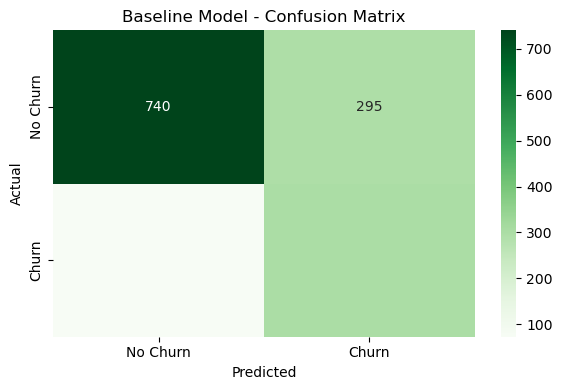

Confusion Matrix:
[[740 295]
 [ 73 301]]

Rows = Actual, Columns = Predicted
Format: [[True Negative, False Positive], [False Negative, True Positive]]


In [72]:
#  BUILD ANN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seed for reproducibility
tf.random.set_seed(42)

# Build the baseline model
baseline_model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
baseline_model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print the model summary
baseline_model.summary()


# TRAIN THE MODEL
# Calculate class weights to handle imbalance

# Class weighting addresses the imbalance identified in EDA — 73.5% No Churn
# vs 26.5% Churn. Without correction, the model would be biased toward 
# predicting the majority class (No Churn) and miss actual churners.
# 'balanced' automatically calculates weights inversely proportional to 
# class frequency — churners get penalised more heavily when missed,
# forcing the model to take them seriously during training.

from sklearn.utils.class_weight import compute_class_weight
import numpy as np


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print('Class weights:', class_weight_dict)

# Train the model
baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

# EVALUATE THE MODEL
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_pred_prob = baseline_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification report
print('=== BASELINE MODEL PERFORMANCE ===')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Baseline Model - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print()
print('Rows = Actual, Columns = Predicted')
print('Format: [[True Negative, False Positive], [False Negative, True Positive]]')

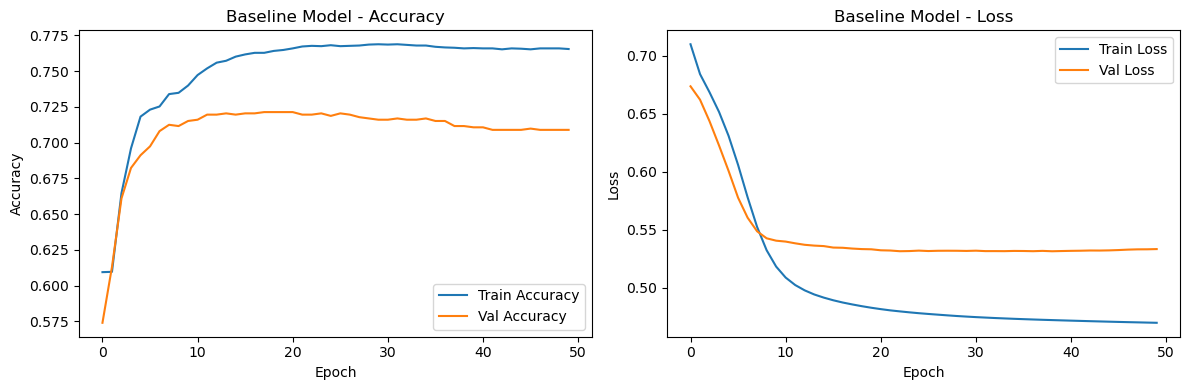

In [73]:
# VISUALISE TRAINING HISTORY

# Plot training vs validation accuracy and loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(baseline_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(baseline_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Baseline Model - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(baseline_history.history['loss'], label='Train Loss')
axes[1].plot(baseline_history.history['val_loss'], label='Val Loss')
axes[1].set_title('Baseline Model - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [74]:
# BUILD AND TRAIN THE ADAM OPTIMIZED MODEL

# Set random seed for reproducibility
tf.random.set_seed(42)

# Build the Adam model - same architecture as baseline
adam_model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile with Adam optimizer
adam_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
adam_history = adam_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7247 - loss: 0.6739 - val_accuracy: 0.7436 - val_loss: 0.5858
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7641 - loss: 0.5266 - val_accuracy: 0.7143 - val_loss: 0.5649
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7599 - loss: 0.4900 - val_accuracy: 0.7090 - val_loss: 0.5556
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7602 - loss: 0.4856 - val_accuracy: 0.7134 - val_loss: 0.5491
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7579 - loss: 0.4826 - val_accuracy: 0.7143 - val_loss: 0.5463
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7584 - loss: 0.4802 - val_accuracy: 0.7143 - val_loss: 0.5433
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7604 - loss: 0.4781 - val_accuracy: 0.7152 - val_loss: 0.5408
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7595 - loss: 0.4763 - val_accuracy: 0

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== ADAM MODEL PERFORMANCE ===
              precision    recall  f1-score   support

    No Churn       0.92      0.70      0.80      1035
       Churn       0.50      0.83      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.81      0.74      0.75      1409



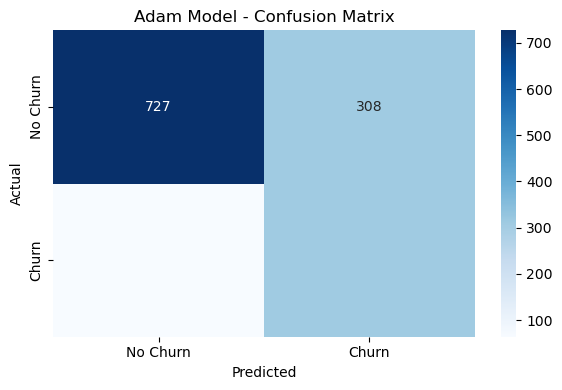

Confusion Matrix:
[[727 308]
 [ 64 310]]


In [75]:
# EVALUATE ADAM MODEL

# Get predictions
y_pred_adam_prob = adam_model.predict(X_test)
y_pred_adam = (y_pred_adam_prob > 0.5).astype(int)

# Classification report
print('=== ADAM MODEL PERFORMANCE ===')
print(classification_report(y_test, y_pred_adam, target_names=['No Churn', 'Churn']))

# Confusion matrix
cm_adam = confusion_matrix(y_test, y_pred_adam)
plt.figure(figsize=(6,4))
sns.heatmap(cm_adam, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Adam Model - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print('Confusion Matrix:')
print(cm_adam)

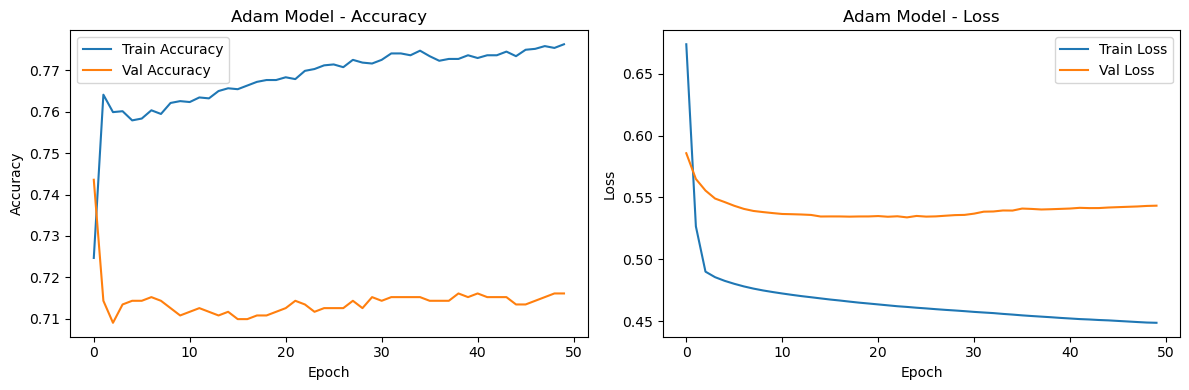

In [76]:
# ADAM TRAINING HISTORY
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(adam_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(adam_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Adam Model - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(adam_history.history['loss'], label='Train Loss')
axes[1].plot(adam_history.history['val_loss'], label='Val Loss')
axes[1].set_title('Adam Model - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [77]:
#  BUILD AND TRAIN RMSPROP MODEL
tf.random.set_seed(42)

rms_model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

rms_model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rms_history = rms_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6909 - loss: 0.5659 - val_accuracy: 0.7232 - val_loss: 0.5758
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7639 - loss: 0.5018 - val_accuracy: 0.7329 - val_loss: 0.5587
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7661 - loss: 0.4901 - val_accuracy: 0.7240 - val_loss: 0.5509
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7661 - loss: 0.4844 - val_accuracy: 0.7249 - val_loss: 0.5468
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7659 - loss: 0.4807 - val_accuracy: 0.7196 - val_loss: 0.5454
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7677 - loss: 0.4781 - val_accuracy: 0.7258 - val_loss: 0.5417
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7675 - loss: 0.4761 - val_accuracy: 0.7258 - val_loss: 0.5403
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7661 - loss: 0.4745 - val_accuracy: 0

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
=== RMSPROP MODEL PERFORMANCE ===
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



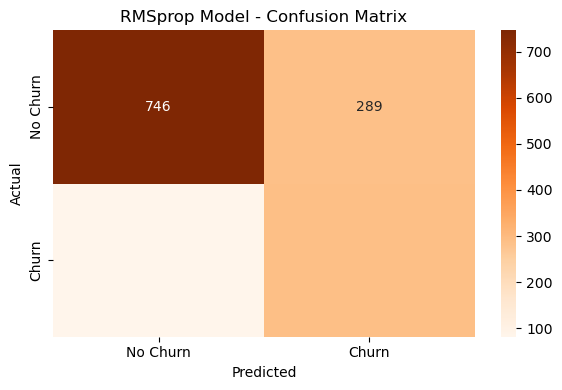

Confusion Matrix:
[[746 289]
 [ 82 292]]


In [78]:
# EVALUATE RMSPROP MODEL
y_pred_rms_prob = rms_model.predict(X_test)
y_pred_rms = (y_pred_rms_prob > 0.5).astype(int)

print('=== RMSPROP MODEL PERFORMANCE ===')
print(classification_report(y_test, y_pred_rms, target_names=['No Churn', 'Churn']))

cm_rms = confusion_matrix(y_test, y_pred_rms)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rms, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('RMSprop Model - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print('Confusion Matrix:')
print(cm_rms)

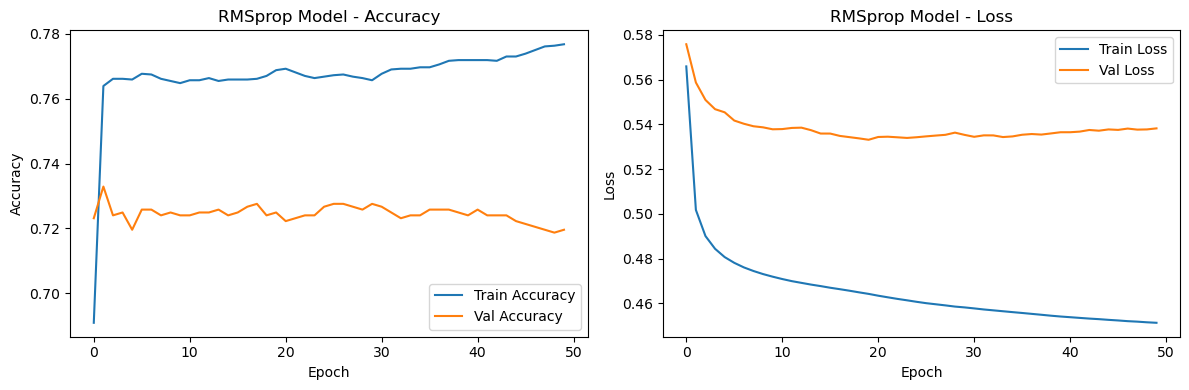

In [79]:
# RMSPROP TRAINING HISTORY
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(rms_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(rms_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('RMSprop Model - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(rms_history.history['loss'], label='Train Loss')
axes[1].plot(rms_history.history['val_loss'], label='Val Loss')
axes[1].set_title('RMSprop Model - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [80]:
# BUILD AND TRAIN SGD with TUNING MODEL
tf.random.set_seed(42)

sgd_tuned_model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

sgd_tuned_model.compile(
    optimizer=keras.optimizers.SGD(
        learning_rate=0.01, 
        momentum=0.9),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

sgd_tuned_history = sgd_tuned_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6687 - loss: 0.5799 - val_accuracy: 0.7010 - val_loss: 0.6159
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7621 - loss: 0.5002 - val_accuracy: 0.6948 - val_loss: 0.6000
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7641 - loss: 0.4900 - val_accuracy: 0.7010 - val_loss: 0.5936
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7668 - loss: 0.4851 - val_accuracy: 0.7019 - val_loss: 0.5877
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7666 - loss: 0.4815 - val_accuracy: 0.7010 - val_loss: 0.5882
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7650 - loss: 0.4792 - val_accuracy: 0.7028 - val_loss: 0.5839
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7635 - loss: 0.4774 - val_accuracy: 0.7001 - val_loss: 0.5823
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7664 - loss: 0.4760 - val_accuracy: 

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== TUNED SGD MODEL PERFORMANCE ===
              precision    recall  f1-score   support

    No Churn       0.92      0.69      0.79      1035
       Churn       0.49      0.83      0.62       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.73      0.74      1409



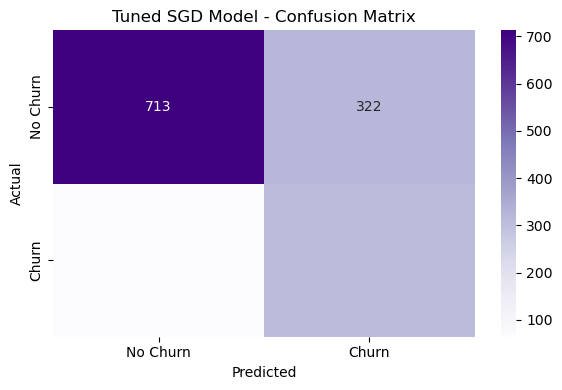

Confusion Matrix:
[[713 322]
 [ 64 310]]


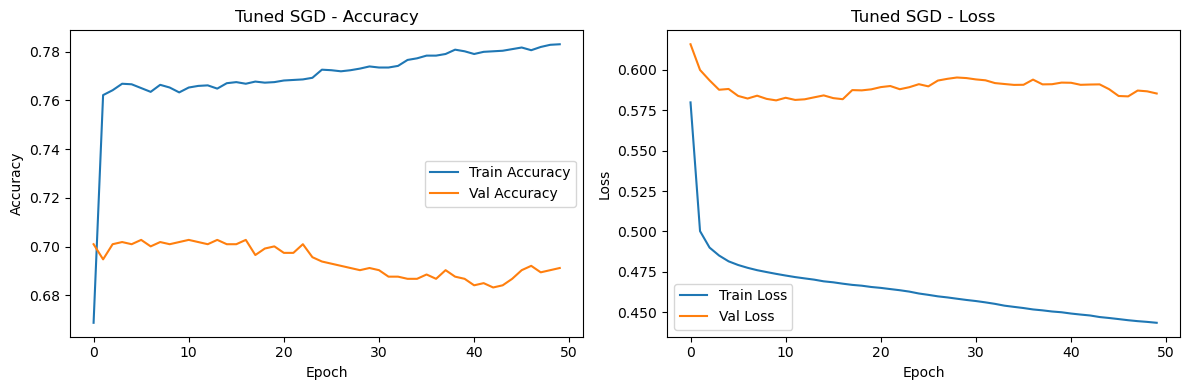

In [81]:
# EVALUATE TUNED SGD
y_pred_sgd_tuned_prob = sgd_tuned_model.predict(X_test)
y_pred_sgd_tuned = (y_pred_sgd_tuned_prob > 0.5).astype(int)

print('=== TUNED SGD MODEL PERFORMANCE ===')
print(classification_report(y_test, y_pred_sgd_tuned, 
      target_names=['No Churn', 'Churn']))

cm_sgd_tuned = confusion_matrix(y_test, y_pred_sgd_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm_sgd_tuned, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Tuned SGD Model - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print('Confusion Matrix:')
print(cm_sgd_tuned)


# TUNED SGD TRAINING HISTORY
# Visualise how training and validation accuracy/loss evolved across
# 50 epochs — reveals whether momentum and higher learning rate 
# caused faster learning or overfitting compared to other optimizers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sgd_tuned_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(sgd_tuned_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Tuned SGD - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(sgd_tuned_history.history['loss'], label='Train Loss')
axes[1].plot(sgd_tuned_history.history['val_loss'], label='Val Loss')
axes[1].set_title('Tuned SGD - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

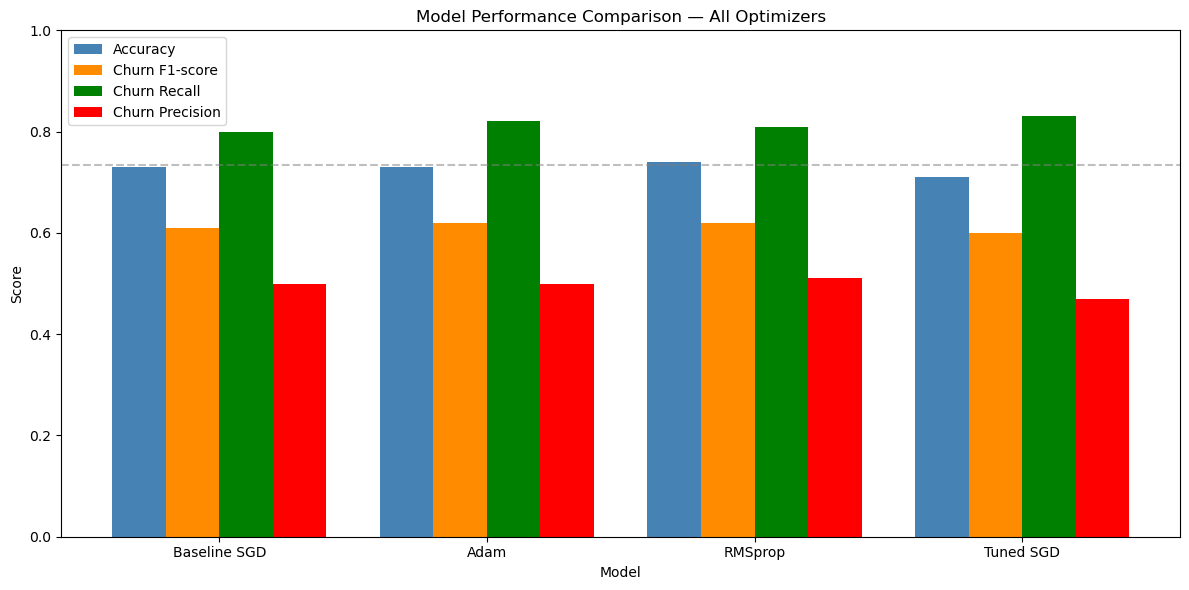

In [82]:
# FINAL COMPARISON VISUALISATION FOR THE FOUR MODELS
# Summary comparison chart
models = ['Baseline SGD', 'Adam', 'RMSprop', 'Tuned SGD']
accuracy = [0.73, 0.73, 0.74, 0.71]
f1_churn = [0.61, 0.62, 0.62, 0.60]
recall_churn = [0.80, 0.82, 0.81, 0.83]
precision_churn = [0.50, 0.50, 0.51, 0.47]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='steelblue')
ax.bar(x - 0.5*width, f1_churn, width, label='Churn F1-score', color='darkorange')
ax.bar(x + 0.5*width, recall_churn, width, label='Churn Recall', color='green')
ax.bar(x + 1.5*width, precision_churn, width, label='Churn Precision', color='red')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — All Optimizers')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.0)
ax.axhline(y=0.735, color='grey', linestyle='--', alpha=0.5, label='Naive baseline')

plt.tight_layout()
plt.show()

In [83]:
# SAVE FOUR MODELS
baseline_model.save('baseline_sgd_model.keras')
adam_model.save('adam_model.keras')
rms_model.save('rmsprop_model.keras')
sgd_tuned_model.save('tuned_sgd_model.keras')

print('All models saved successfully.')

All models saved successfully.


In [84]:
# SAVE ALL THE CHARTS 
# ── 1. Churn Distribution ──────────────────────────────────────────
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('01_churn_distribution.png', dpi=150)
plt.close()

# ── 2. Tenure & Monthly Charges vs Churn ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Tenure vs Churn')
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Monthly Charges vs Churn')
plt.tight_layout()
plt.savefig('02_numerical_vs_churn.png', dpi=150)
plt.close()

# ── 3. Contract Type vs Churn ──────────────────────────────────────
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Contract Type vs Churn')
plt.tight_layout()
plt.savefig('03_contract_vs_churn.png', dpi=150)
plt.close()

# ── 4. Internet Service vs Churn ───────────────────────────────────
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')
plt.title('Internet Service vs Churn')
plt.tight_layout()
plt.savefig('04_internet_vs_churn.png', dpi=150)
plt.close()

# ── 5. Payment Method vs Churn ─────────────────────────────────────
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set2')
plt.title('Payment Method vs Churn')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('05_payment_vs_churn.png', dpi=150)
plt.close()

# ── 6. Baseline Learning Curves ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(baseline_history.history['accuracy'], label='Train')
axes[0].plot(baseline_history.history['val_accuracy'], label='Val')
axes[0].set_title('Baseline SGD - Accuracy')
axes[0].legend()
axes[1].plot(baseline_history.history['loss'], label='Train')
axes[1].plot(baseline_history.history['val_loss'], label='Val')
axes[1].set_title('Baseline SGD - Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('06_baseline_learning_curves.png', dpi=150)
plt.close()

# ── 7. Adam Learning Curves ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(adam_history.history['accuracy'], label='Train')
axes[0].plot(adam_history.history['val_accuracy'], label='Val')
axes[0].set_title('Adam - Accuracy')
axes[0].legend()
axes[1].plot(adam_history.history['loss'], label='Train')
axes[1].plot(adam_history.history['val_loss'], label='Val')
axes[1].set_title('Adam - Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('07_adam_learning_curves.png', dpi=150)
plt.close()

# ── 8. RMSprop Learning Curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rms_history.history['accuracy'], label='Train')
axes[0].plot(rms_history.history['val_accuracy'], label='Val')
axes[0].set_title('RMSprop - Accuracy')
axes[0].legend()
axes[1].plot(rms_history.history['loss'], label='Train')
axes[1].plot(rms_history.history['val_loss'], label='Val')
axes[1].set_title('RMSprop - Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('08_rmsprop_learning_curves.png', dpi=150)
plt.close()

# ── 9. Tuned SGD Learning Curves ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sgd_tuned_history.history['accuracy'], label='Train')
axes[0].plot(sgd_tuned_history.history['val_accuracy'], label='Val')
axes[0].set_title('Tuned SGD - Accuracy')
axes[0].legend()
axes[1].plot(sgd_tuned_history.history['loss'], label='Train')
axes[1].plot(sgd_tuned_history.history['val_loss'], label='Val')
axes[1].set_title('Tuned SGD - Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('09_tuned_sgd_learning_curves.png', dpi=150)
plt.close()

# ── 10. Confusion Matrices ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
cms = [
    (confusion_matrix(y_test, y_pred), 'Baseline SGD', 'Greens'),
    (confusion_matrix(y_test, y_pred_adam), 'Adam', 'Blues'),
    (confusion_matrix(y_test, y_pred_rms), 'RMSprop', 'Oranges'),
    (confusion_matrix(y_test, y_pred_sgd_tuned), 'Tuned SGD', 'Purples')
]
for ax, (cm_data, title, cmap) in zip(axes, cms):
    sns.heatmap(cm_data, annot=True, fmt='d', cmap=cmap,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'], ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('10_confusion_matrices.png', dpi=150)
plt.close()

# ── 11. Final Comparison Chart ─────────────────────────────────────
models = ['Baseline SGD', 'Adam', 'RMSprop', 'Tuned SGD']
accuracy = [0.73, 0.73, 0.74, 0.71]
f1_churn = [0.61, 0.62, 0.62, 0.60]
recall_churn = [0.80, 0.82, 0.81, 0.83]
precision_churn = [0.50, 0.50, 0.51, 0.47]

x = np.arange(len(models))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='steelblue')
ax.bar(x - 0.5*width, f1_churn, width, label='Churn F1-score', color='darkorange')
ax.bar(x + 0.5*width, recall_churn, width, label='Churn Recall', color='green')
ax.bar(x + 1.5*width, precision_churn, width, label='Churn Precision', color='red')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — All Optimizers')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.0)
ax.axhline(y=0.735, color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('11_model_comparison.png', dpi=150)
plt.close()

print('All 11 charts saved successfully.')

All 11 charts saved successfully.
